step1

In [17]:
# Cell 0: Title & imports
# Set MODEL_NAME to one of: "LogisticRegression", "DecisionTree", "RandomForest"
MODEL_NAME = "LogisticRegression"  # change per notebook

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression

step2: load data

In [18]:
# Load data
train_df = pd.read_csv("../data/train_Data.csv")
test_df = pd.read_csv("../data/test_Data.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nColumns:", train_df.columns.tolist())

# Show first rows
train_df.head()

Train shape: (80000, 10)
Test shape: (20000, 10)

Columns: ['Unnamed: 0', 'gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


,Unnamed: 0,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,Female,80.0,0,1,never,25.19,6.6,140,0
1,1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,2,Male,28.0,0,0,never,27.32,5.7,158,0
3,3,Female,36.0,0,0,current,23.45,5.0,155,0
4,4,Male,76.0,1,1,current,20.14,4.8,155,0


step3:EDA

Shape: (80000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           80000 non-null  int64  
 1   gender               80000 non-null  object 
 2   age                  80000 non-null  float64
 3   hypertension         80000 non-null  int64  
 4   heart_disease        80000 non-null  int64  
 5   smoking_history      80000 non-null  object 
 6   bmi                  80000 non-null  float64
 7   HbA1c_level          80000 non-null  float64
 8   blood_glucose_level  80000 non-null  int64  
 9   diabetes             80000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 6.1+ MB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,80000.0,NaN,NaN,NaN,39999.5,23094.155105,0.0,19999.75,39999.5,59999.25,79999.0
gender,80000,3,Female,46775,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,80000.0,NaN,NaN,NaN,41.880534,22.506837,0.08,24.0,43.0,60.0,80.0
hypertension,80000.0,NaN,NaN,NaN,0.074137,0.261996,0.0,0.0,0.0,0.0,1.0
heart_disease,80000.0,NaN,NaN,NaN,0.039,0.193596,0.0,0.0,0.0,0.0,1.0
smoking_history,80000,6,No Info,28626,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,80000.0,NaN,NaN,NaN,27.331165,6.638644,10.01,23.65,27.32,29.56,95.22
HbA1c_level,80000.0,NaN,NaN,NaN,5.526496,1.071879,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,80000.0,NaN,NaN,NaN,138.0242,40.786536,80.0,100.0,140.0,159.0,300.0
diabetes,80000.0,NaN,NaN,NaN,0.0853,0.279329,0.0,0.0,0.0,0.0,1.0


Target distribution:
 diabetes
0    73176
1     6824
Name: count, dtype: int64
Missing values:
 Unnamed: 0             0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


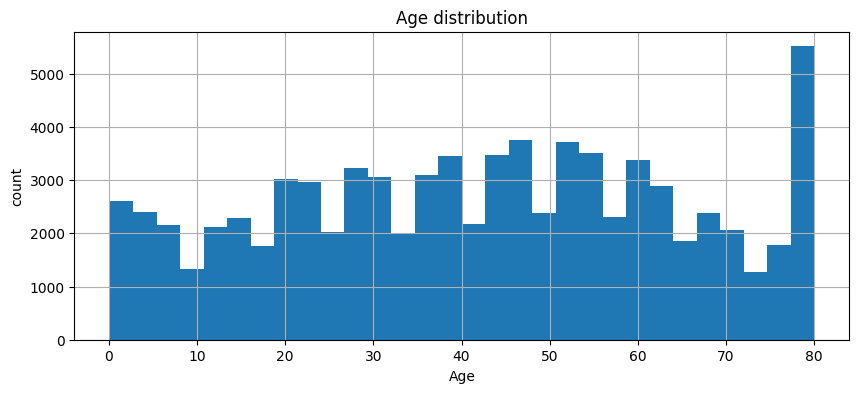

<Figure size 800x600 with 0 Axes>

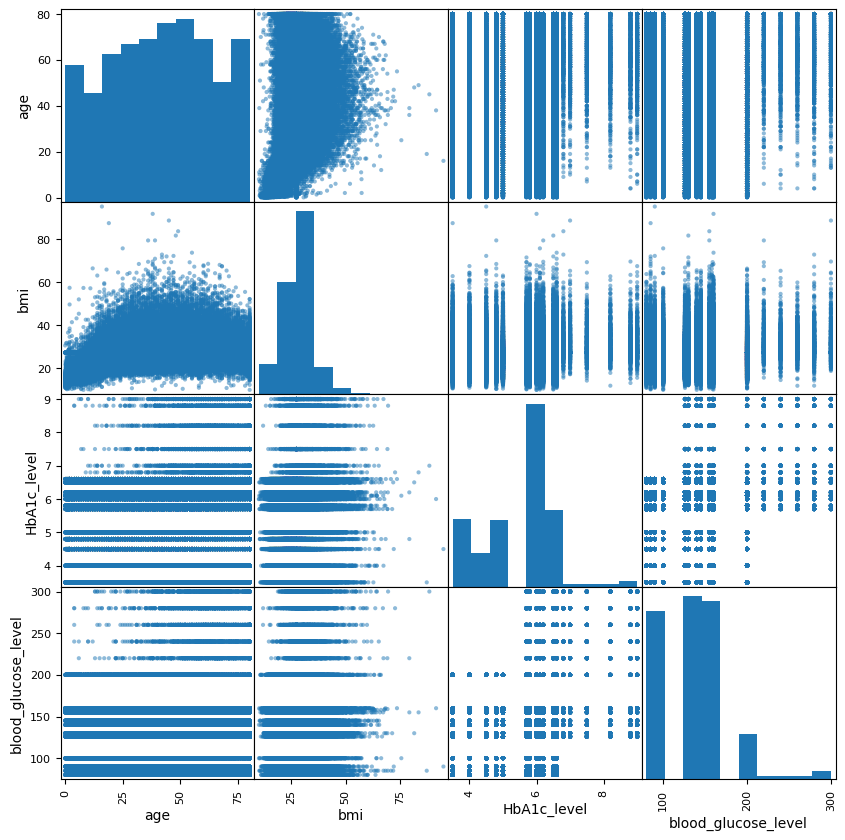

In [19]:
# Cell 2: EDA
print("Shape:", train_df.shape)
print(train_df.info())
display(train_df.describe(include='all').T)

# Check target distribution
print("Target distribution:\n", train_df['diabetes'].value_counts())

# Missing values
print("Missing values:\n", train_df.isnull().sum())

# Simple plots
plt.figure(figsize=(10,4))
train_df['age'].hist(bins=30)
plt.title('Age distribution')
plt.xlabel('Age')
plt.ylabel('count')
plt.savefig("outputs/age_hist.png")
plt.show()

# Scatter matrix with corrected column names
cols = [c for c in ['age','bmi','HbA1c_level','blood_glucose_level'] if c in train_df.columns]

if cols:
    plt.figure(figsize=(8,6))
    pd.plotting.scatter_matrix(train_df[cols], figsize=(10,10))
    plt.savefig("outputs/scatter_matrix.png")
    plt.show()
else:
    print("⚠️ None of the expected columns found in dataset.")


In [20]:
# Create outputs directory if it doesn't exist
os.makedirs("outputs", exist_ok=True)

step4:preprocessing

In [21]:
# --- Cell 3.5: Define features, target, and preprocessing ---
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Separate features and target
X = train_df.drop("diabetes", axis=1)
y = train_df["diabetes"]

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

# Define transformers
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine into preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_cols),
        ("cat", cat_transformer, cat_cols)
    ]
)


step5:Set features, detect types, and preprocessing pipeline

In [22]:
# --- Cell 4: Train/test split and model training ---
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from datetime import datetime

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# Build model with preprocessing
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)

full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', dt_model)
])

# Fit
full_pipeline.fit(X_train, y_train)

# Predict
y_pred = full_pipeline.predict(X_test)

# Metrics
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
}

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", metrics["accuracy"])

# --- Cell 5: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
os.makedirs("outputs", exist_ok=True)
cm_path = "outputs/confusion_matrix.png"
plt.savefig(cm_path, bbox_inches="tight")
plt.close()
print("Saved confusion matrix to:", cm_path)

# --- Cell 6: Save pipeline ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_NAME = "DecisionTree"
model_filename = f"outputs/pipeline_{MODEL_NAME}_{timestamp}.joblib"
joblib.dump(full_pipeline, model_filename)
print("Saved pipeline to:", model_filename)

# --- Cell 7: Create PDF report with matplotlib ---
def create_pdf_report_matplotlib(filename_pdf, metrics, cm_path, model_path):
    fig, ax = plt.subplots(figsize=(8.5, 11))  # A4 size
    ax.axis("off")

    # Title
    y = 1.0
    ax.text(0.5, y, f"Diabetes Classification Report - {MODEL_NAME}",
            ha="center", va="top", fontsize=16, fontweight="bold")
    y -= 0.08

    # Model info
    ax.text(0.01, y, f"Model saved at: {os.path.basename(model_path)}", fontsize=12, va="top")
    y -= 0.05
    ax.text(0.01, y, f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}", fontsize=12, va="top")
    y -= 0.08

    # Metrics
    ax.text(0.01, y, "Metrics:", fontsize=13, fontweight="bold", va="top")
    y -= 0.05
    for k, v in metrics.items():
        ax.text(0.05, y, f"{k.capitalize()}: {v:.4f}", fontsize=12, va="top")
        y -= 0.04

    # Insert confusion matrix image
    if os.path.exists(cm_path):
        img = plt.imread(cm_path)
        newax = fig.add_axes([0.15, 0.05, 0.7, 0.35], anchor='S')
        newax.imshow(img)
        newax.axis('off')
        ax.text(0.01, y-0.02, "Confusion Matrix:", fontsize=13, fontweight="bold", va="top")

    # Save as PDF
    plt.savefig(filename_pdf, bbox_inches="tight")
    plt.close()
    print("PDF report created:", filename_pdf)

# Generate PDF
pdf_name = f"outputs/report_{MODEL_NAME}_{timestamp}.pdf"
create_pdf_report_matplotlib(pdf_name, metrics, cm_path, model_filename)


Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     14635
           1       1.00      0.67      0.80      1365

    accuracy                           0.97     16000
   macro avg       0.99      0.84      0.89     16000
weighted avg       0.97      0.97      0.97     16000

Accuracy: 0.9720625
Saved confusion matrix to: outputs/confusion_matrix.png
Saved pipeline to: outputs/pipeline_DecisionTree_20250902_010539.joblib
PDF report created: outputs/report_DecisionTree_20250902_010539.pdf


In [24]:
import joblib

joblib.dump(dt_model, "DecisionTree_model.pkl")
print("✅ Model saved")

✅ Model saved
